# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 4. Demonstração (Demonstration)

**Objetivo Acadêmico:** A utilização de **Support Vector Regression (SVR)** neste notebook visa explorar a minimização do risco estrutural em vez do risco empírico clássico. O SVR é particularmente eficaz em capturar relações não-lineares complexas através do *kernel trick*. No contexto do DSR, esta etapa representa a exploração do espaço de soluções tecnológicas para encontrar o design mais eficaz para o problema de predição de demanda (Rodrigues et al., 2024).


# 07c - Modelagem: Support Vector Regression (SVR)
Neste notebook, aplicamos **SVR** para a predição do `total_servido`.

**Estratégia**: O SVR é extremamente sensível à escala e à dimensionalidade. Utilizaremos **RFECV** para encontrar o conjunto ótimo de variáveis e um **Grid Search** para otimizar os parâmetros do kernel RBF.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import joblib
import os

# Configurações
BASE_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

df = pd.read_csv(BASE_SELECIONADA)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

print(f"📦 Base carregada: {df.shape[0]} registros.")

📦 Base carregada: 191 registros.


In [2]:
# Validação da Base 2023-2025
print(f"📊 Shape da base: {df.shape}")
print(f"📅 Período: {df['data'].min()} até {df['data'].max()}")

📊 Shape da base: (191, 52)
📅 Período: 2023-08-01 00:00:00 até 2025-08-22 00:00:00


In [3]:
# 1. Divisão Treino/Teste (Temporal)
train_size = int(len(df) * 0.8)
X_full = df.drop(columns=['data', TARGET])
y_full = df[TARGET]

X_train_full = X_full.iloc[:train_size]
y_train = y_full.iloc[:train_size]
X_test_full = X_full.iloc[train_size:]
y_test = y_full.iloc[train_size:]

# 2. Seleção de Variáveis (RFECV)
print("🔄 Selecionando variáveis via RFECV para SVR...")
rf = RandomForestRegressor(n_estimators=50, random_state=42)
selector = RFECV(estimator=rf, step=1, cv=5, scoring='neg_mean_absolute_error')
selector.fit(X_train_full, y_train)

selected_features = X_full.columns[selector.support_].tolist()
print(f"✅ RFECV concluído! Número ideal de variáveis: {len(selected_features)}")
print(f"📌 Features selecionadas: {selected_features}")

X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

# 3. Normalização (Essencial para SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📈 Treino: {len(X_train)} dias | Teste: {len(X_test)} dias")

🔄 Selecionando variáveis via RFECV para SVR...
✅ RFECV concluído! Número ideal de variáveis: 5
📌 Features selecionadas: ['total_reservas', 'erro_planejamento_ontem', 'reservas_media_movel_5d', 'total_reservas_lag_2', 'reservas_media_movel_3d']
📈 Treino: 152 dias | Teste: 39 dias


In [4]:
# Otimizando C, epsilon e gamma para o kernel RBF
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1, 5, 10],
    'gamma': ['scale', 'auto']
}

print("🔄 Buscando melhores hiperparâmetros (GridSearch)...")
grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print(f"🎯 Melhores Parâmetros: {grid.best_params_}")

# Avaliação no Teste
preds = best_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"\n📊 Resultados Finais (SVR):")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

🔄 Buscando melhores hiperparâmetros (GridSearch)...
🎯 Melhores Parâmetros: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto'}

📊 Resultados Finais (SVR):
MAE: 23.6295
RMSE: 30.9347
R2: 0.2554


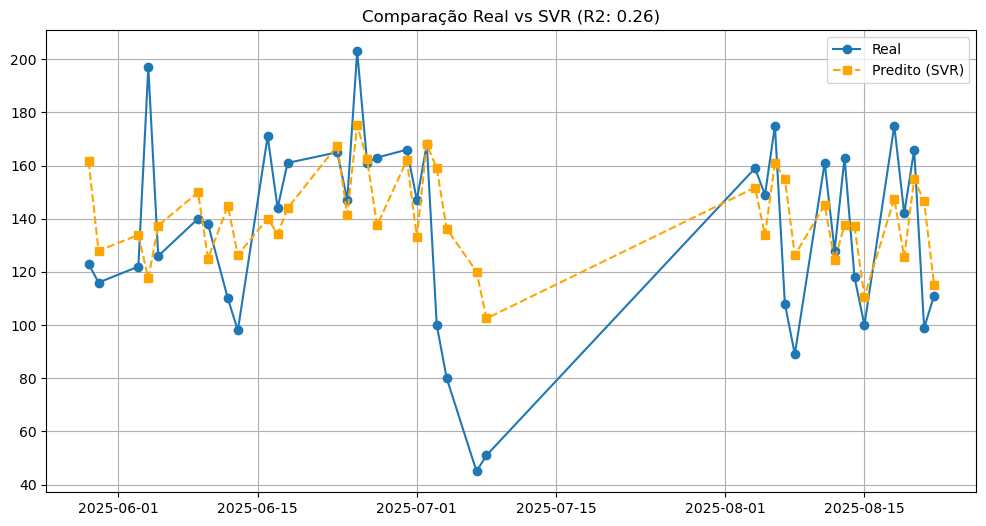

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df.iloc[train_size:]['data'], y_test, label='Real', marker='o')
plt.plot(df.iloc[train_size:]['data'], preds, label='Predito (SVR)', linestyle='--', marker='s', color='orange')
plt.title(f"Comparação Real vs SVR (R2: {r2:.2f})")
plt.legend()
plt.grid(True)
plt.show()